In [89]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.transforms as transforms
from glob import glob
import os
import SimpleITK as sitk
from typing import Tuple, List, Dict, Optional, Callable
from lungmask import LMInferer
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

In [16]:
print(f'Versão do Torch: {torch.__version__}')

Versão do Torch: 2.3.0.post100
Versão do MatPlotLib: 3.8.4


In [83]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

RAW_DATA_FOLDER = '/home/arthur/Documentos/transformers/data/atm22/'
PROCESSED_DATA_FOLDER = '/home/arthur/Documentos/generativas/dgm-2024.2/projetos/PulmoNet/data/processed'
inferer = LMInferer()

In [ ]:
def save_lung_segmentations(output_path, segmentor):
    input_path = os.path.join(RAW_DATA_FOLDER, 'train', 'imagesTr')
    output_path = os.path.join(PROCESSED_DATA_FOLDER, 'train', 'lungTr')

    cts = sorted(glob(os.path.join(input_path, '*.nii.gz')))
    for file in cts:
        img = sitk.ReadImage(cts)
        mask = segmentor.apply(img)
        mask = sitk.GetArrayFromImage(mask)
        np.savez_compressed(os.path.join())


In [150]:
glob(RAW_DATA_FOLDER)

['/home/arthur/Documentos/transformers/data/atm22/']

In [101]:
class rawCTData(Dataset):
    def __init__(self, mode: str, transform: Optional[Callable] = None):
        super().__init__()
        if mode == 'train':
            self.cts = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "imagesTr", "*.nii.gz")))
            self.labels = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "labelsTr", "*.nii.gz")))
        else:
            self.cts = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "*.nii.gz")))
        self.transform = transform

    def __len__(self):
        return len(self.cts)
    
    def __getitem__(self, idx: int):
        '''
        Carregar, transformar e retornar o item 'i' do dataset
        Cada aquisição envolve 4 sequências presentes na dimensão de canais da imagem
        As sequências mapeam com a string RawMRIDataset.SEQUENCE
        '''
        ct_path = self.cts[idx]
        ct_labels_path = self.labels[idx]

        # Ler imagem usando a biblioteca SimpleITK, o objeto image contêm também metadados
        print(f'Reading {ct_path} and {ct_labels_path}.......')
        image = sitk.ReadImage(ct_path)
        label = sitk.ReadImage(ct_labels_path)

        # Converter imagem para array numpy na variável 'ct'
        print("Converting to array")
        ct = sitk.GetArrayFromImage(image)
        ct_label = sitk.GetArrayFromImage(label)

        # Se uma função de transformada foi passada para o dataset, aplicá-la
        if self.transform is not None:
            ct = self.transform(ct)
        print(ct.shape)
        # Retornar a imagem e metadados
        return ct, ct_label

In [86]:
def check_rawCTData_class():
    test=rawCTData('train')
    random.choice(test)

In [147]:
def return_volume_segmentation(ct_volume, segmentor):
    img = sitk.GetImageFromArray(ct_volume)
    print(f'Formato da Imagem: {img.GetSize()}, Formato do Volume: {ct_volume.shape}')
    return img

test = return_volume_segmentation(sample_img, inferer)

In [78]:
class MinMaxNormalize():
    '''
    Normaliza a imagem para o intervalo [0, 1]
    '''
    def __call__(self, x: np.ndarray) -> np.ndarray:
        return (x - x.min()) / (x.max() - x.min())

Reading /home/arthur/Documentos/transformers/data/atm22/train/imagesTr/ATM_173_0000.nii.gz and /home/arthur/Documentos/transformers/data/atm22/train/labelsTr/ATM_173_0000.nii.gz.......
Converting to array
(481, 512, 512)


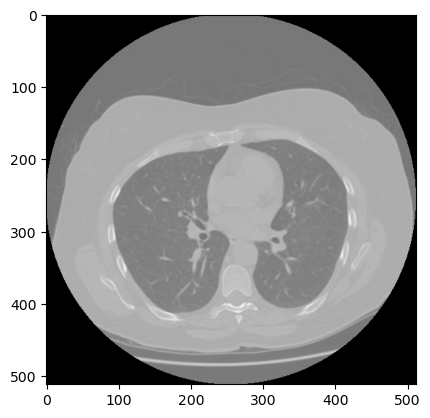

In [102]:
test_data = rawCTData('train', transform=MinMaxNormalize())
sample_img, sample_msk = test_data[len(test_data)//2]
plt.imshow(sample_img[len(sample_img)//2], cmap='gray')


In [107]:
np.unique(sample_lung)

array([0], dtype=uint8)

In [124]:
sample_img.shape

(481, 512, 512)

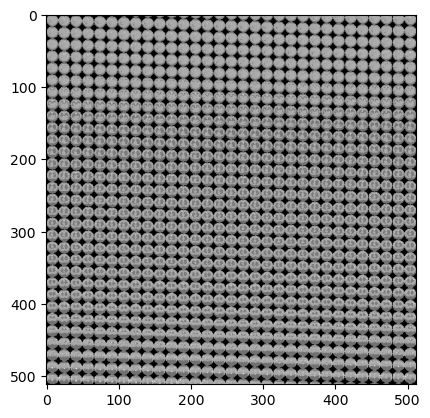

In [138]:
plt.imshow(sitk.GetArrayFromImage(a[0]), cmap='gray')

In [116]:
512*512*481

126091264

In [108]:
sitk.GetImageFromArray(sample_img)

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'std::vector< itk::simple::Image >::value_type *' at 0x7f4a60996c10> >

In [103]:
sample_lung = inferer.apply(sitk.GetImageFromArray(sample_img))
assert 1 in sample_lung
plt.imshow(sample_lung[len(sample_lung)//2], cmap='gray')

25it [00:06,  3.92it/s]                           

lungmask 2024-09-23 17:01:55 Postprocessing



0it [00:00, ?it/s]


AssertionError: 

In [ ]:
def preprocessing_for_lung():
    transform = MinMaxNormalize()
    file_number = 0
    for mode in ['train']: #, 'val']:
        if mode == 'train':
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode, 'imagesTr'), exist_ok=True)
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode, 'labelTr'), exist_ok=True)
        else:
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode), exist_ok=True)
        raw_data = rawCTData(mode, transform=transform)
        for volume, _ in raw_data:
            segmentation = inferer.apply(volume)
            for slice in range(len(volume)):
                # Só estou processando fatias que tenham pulmão, qualquer quantia de pixels
                if 1 in segmentation[slice]:
                    img_filename = os.path.join(PROCESSED_DATA_FOLDER, mode, 'imagesTr', f"{file_number}.npz")
                    label_filename = os.path.join(PROCESSED_DATA_FOLDER, mode, 'labelsTr',f"{file_number}.npz")
                    file_number += 1
                    np.savez_compressed(img_filename, )

                    



In [ ]:
test = inferer.apply

In [4]:
class lungCTData(Dataset):
    def __init__(self, mode: str, transform: Optional[Callable] = None):
        super().__init__()
        self.cts = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "imagesTr", "*.nii.gz")))
        self.labels = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "labelsTr", "*.nii.gz")))
        self.transform = transform

    def __len__(self):
        return len(self.cts)
    
    def __getitem__(self, idx: int):
        '''
        Carregar, transformar e retornar o item 'i' do dataset
        Cada aquisição envolve 4 sequências presentes na dimensão de canais da imagem
        As sequências mapeam com a string RawMRIDataset.SEQUENCE
        '''
        ct_path = self.cts[idx]
        ct_labels_path = self.labels[idx]

        # Ler imagem usando a biblioteca SimpleITK, o objeto image contêm também metadados
        print(f'Reading {ct_path} and {ct_labels_path}.......')
        image = sitk.ReadImage(ct_path)

        # Converter imagem para array numpy na variável 'mri'
        print("Converting to array")
        ct = sitk.GetArrayFromImage(image)
        segmentation = inferer.apply(ct)  # default model is U-net(R231)

        # Se uma função de transformada foi passada para o dataset, aplicá-la
        if self.transform is not None:
            ct = self.transform(ct)
        print(ct.shape)
        # Retornar a imagem e metadados
        return ct, segmentation

In [79]:
data = lungCTData('train', transform=MinMaxNormalize())

In [80]:
img,seg = data[np.random.randint(len(data))]

Reading /home/arthur/Documentos/transformers/data/atm22/train/imagesTr/ATM_040_0000.nii.gz and /home/arthur/Documentos/transformers/data/atm22/train/labelsTr/ATM_040_0000.nii.gz.......
Converting to array


100%|██████████| 32/32.0 [00:08<00:00,  3.75it/s]

lungmask 2024-09-23 15:02:26 Postprocessing



100%|██████████| 9/9 [00:00<00:00, 48.73it/s]


(640, 512, 512)


In [61]:
np.shape(img[0])

(512, 512)

In [82]:
np.unique(seg, return_counts=True)

(array([0, 1, 2], dtype=uint8), array([157432912,   6042374,   4296874]))

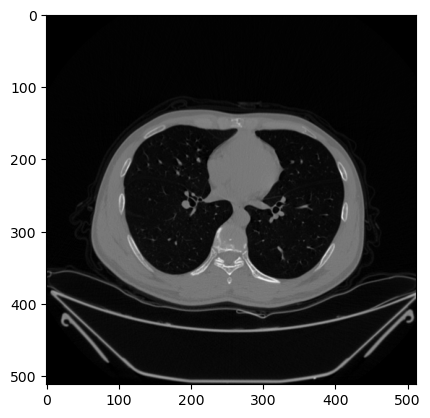

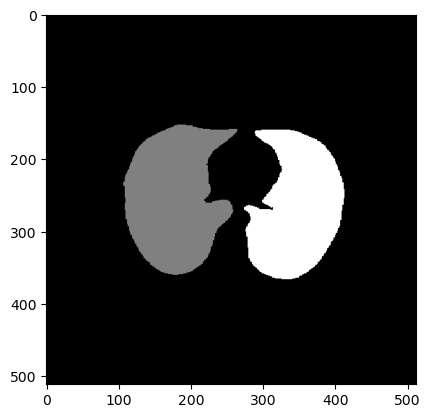

In [67]:
plt.imshow(img[len(img)//2], cmap='gray')
plt.show()
plt.imshow(seg[len(img)//2], cmap='gray')
plt.show()

In [223]:
class MinMaxNormalize():
    '''
    Normaliza a imagem para o intervalo [0, 1]
    '''
    def __call__(self, x: np.ndarray) -> np.ndarray:
        return (x - x.min()) / (x.max() - x.min())

In [244]:
train_data = rawCTData(mode = 'train', transform=MinMaxNormalize())